In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Reduced Shape:", X_pca.shape)

#LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("LDA Reduced Shape:", X_lda.shape)

PCA Reduced Shape: (150, 2)
LDA Reduced Shape: (150, 2)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)
# PCA Classification
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

# LDA Classification
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

clf_lda = LogisticRegression()
clf_lda.fit(X_train_lda, y_train)
y_pred_lda = clf_lda.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("PCA Accuracy:", round(acc_pca, 4))
print("LDA Accuracy:", round(acc_lda, 4))

PCA Accuracy: 0.9111
LDA Accuracy: 1.0


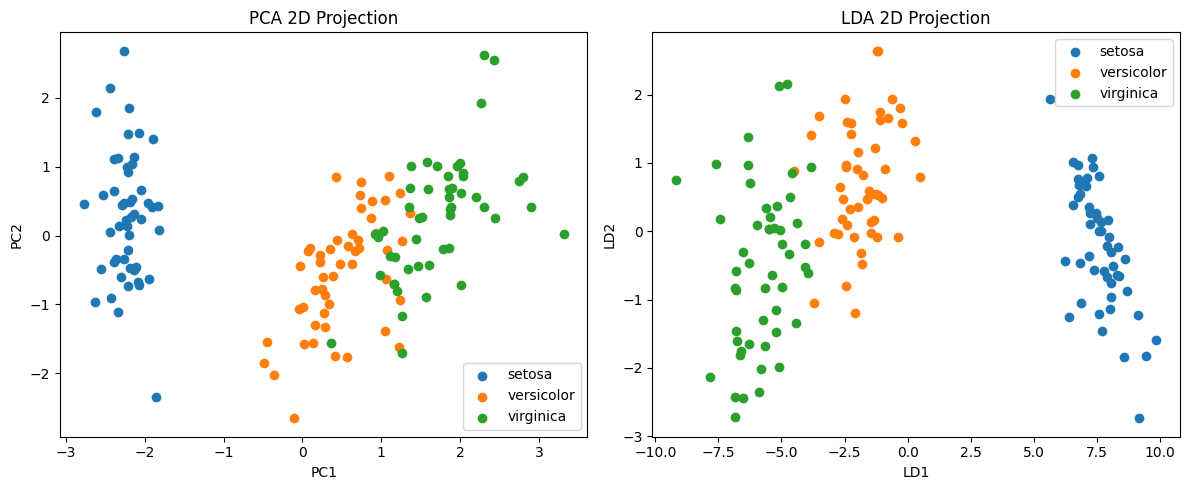

In [ ]:
plt.figure(figsize=(12,5))

#PCA
plt.subplot(1,2,1)
for label in np.unique(y):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=data.target_names[label]
    )
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

#LDA
plt.subplot(1,2,2)
for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=data.target_names[label]
    )
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()

plt.tight_layout()
plt.show()